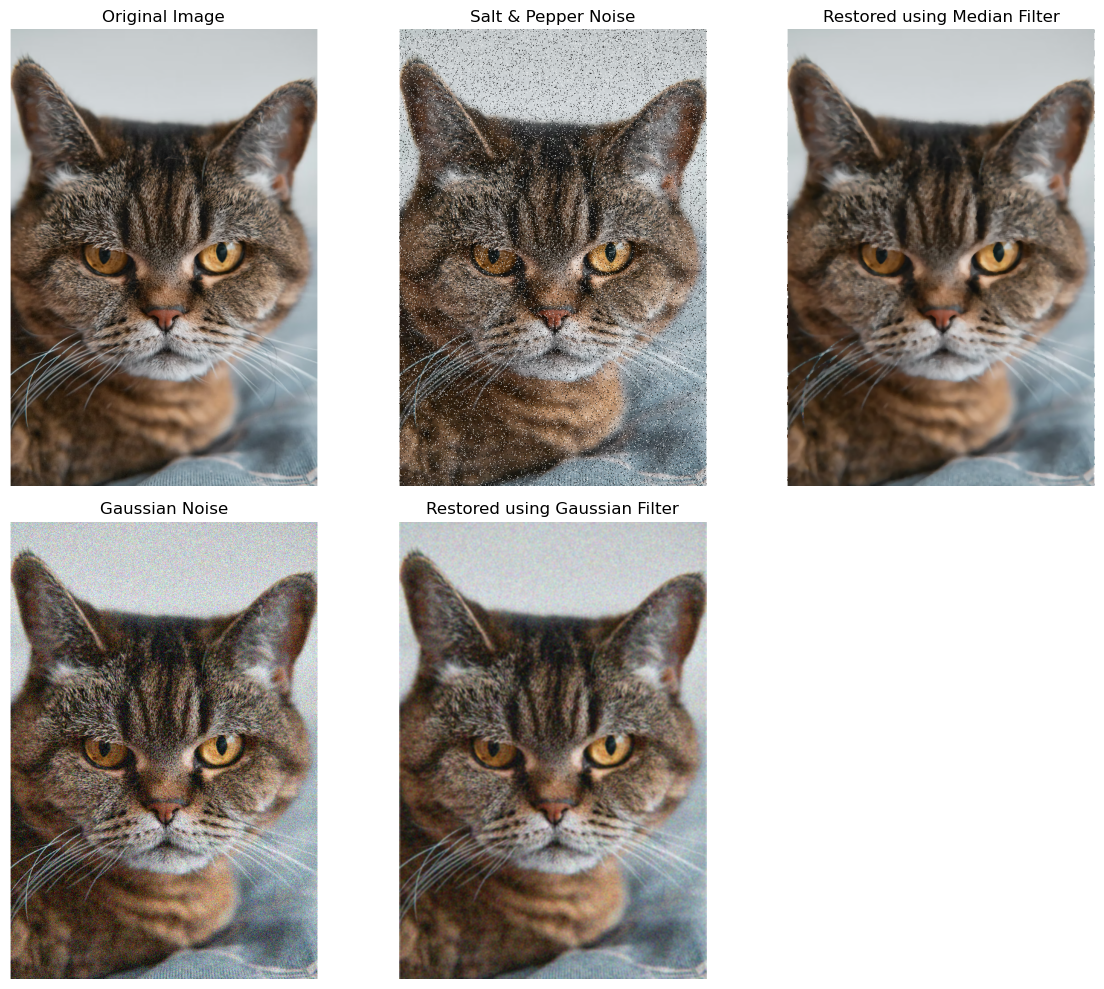

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# 1. Add Salt-and-Pepper Noise

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()

    # Number of pixels to modify
    total_pixels = image.shape[0] * image.shape[1]
    num_pixels = int(amount * total_pixels)

    # Salt noise (white)
    rows = np.random.randint(0, image.shape[0], num_pixels)
    cols = np.random.randint(0, image.shape[1], num_pixels)

    noisy[rows, cols] = 255

    # Pepper noise (black)
    rows = np.random.randint(0, image.shape[0], num_pixels)
    cols = np.random.randint(0, image.shape[1], num_pixels)

    noisy[rows, cols] = 0

    return noisy


salt_pepper = add_salt_pepper_noise(image, 0.05)


# 2. Restore Salt-and-Pepper Noise

# Median filter is effective for salt-and-pepper noise
restored_sp = cv2.medianBlur(salt_pepper, 5)


# 3. Add Gaussian Noise

def add_gaussian_noise(image, mean=0, sigma=25):
    image_float = image.astype(np.float32)

    # Generate Gaussian noise
    noise = np.random.normal(
        mean,
        sigma,
        image.shape
    )

    noisy = image_float + noise

    # Keep pixel values between 0 and 255
    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)


gaussian = add_gaussian_noise(image, 0, 25)


# 4. Restore Gaussian Noise

# Gaussian filter is useful for reducing Gaussian noise
restored_gaussian = cv2.GaussianBlur(
    gaussian,
    (5, 5),
    0
)


# Display Results
plt.figure(figsize=(12, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Salt & Pepper Noise
plt.subplot(2, 3, 2)
plt.imshow(salt_pepper)
plt.title("Salt & Pepper Noise")
plt.axis("off")

# Restored Salt & Pepper
plt.subplot(2, 3, 3)
plt.imshow(restored_sp)
plt.title("Restored using Median Filter")
plt.axis("off")

# Gaussian Noise
plt.subplot(2, 3, 4)
plt.imshow(gaussian)
plt.title("Gaussian Noise")
plt.axis("off")

# Restored Gaussian
plt.subplot(2, 3, 5)
plt.imshow(restored_gaussian)
plt.title("Restored using Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

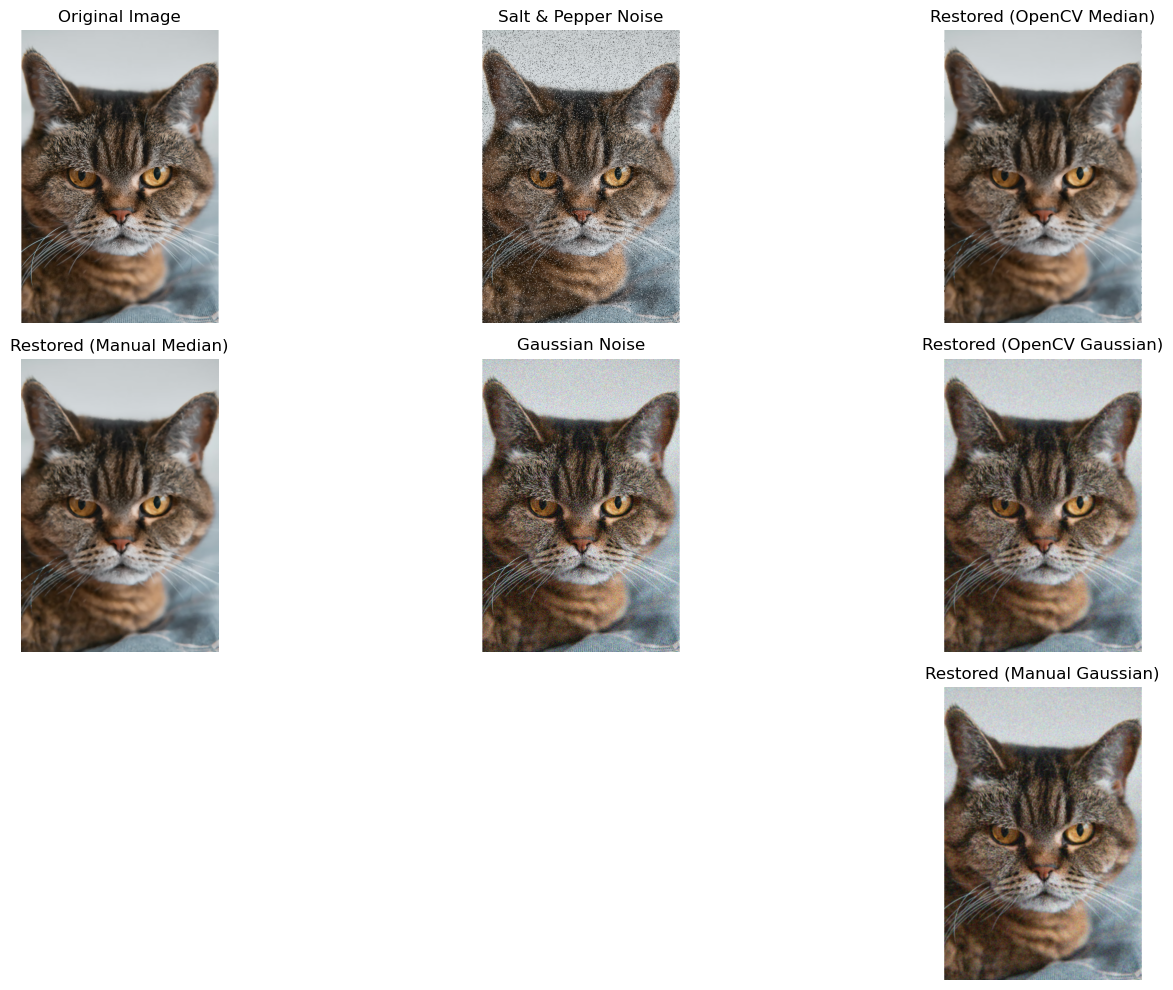

In [2]:
# Manual Implementation of Filters
def median_filter_manual(image, kernel_size=5):
    """Apply median filter manually"""
    h, w = image.shape[:2]
    pad = kernel_size // 2
    output = np.zeros_like(image, dtype=np.uint8)
    
    # Add padding to the image
    if len(image.shape) == 3:
        padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image, pad, mode='reflect')
    
    # Apply filter
    for i in range(h):
        for j in range(w):
            if len(image.shape) == 3:
                for c in range(image.shape[2]):
                    region = padded[i:i+kernel_size, j:j+kernel_size, c]
                    output[i, j, c] = np.median(region)
            else:
                region = padded[i:i+kernel_size, j:j+kernel_size]
                output[i, j] = np.median(region)
    
    return output


def gaussian_blur_manual(image, kernel_size=5, sigma=1.0):
    """Apply Gaussian blur manually"""
    h, w = image.shape[:2]
    pad = kernel_size // 2
    output = np.zeros_like(image, dtype=np.uint8)
    
    # Generate Gaussian kernel
    x = np.arange(-pad, pad + 1)
    y = np.arange(-pad, pad + 1)
    X, Y = np.meshgrid(x, y)
    
    # Gaussian function: G(x,y) = (1/(2*pi*sigma^2)) * exp(-(x^2 + y^2)/(2*sigma^2))
    gaussian_kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()
    
    # Add padding to the image
    if len(image.shape) == 3:
        padded = np.pad(image.astype(np.float32), ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    else:
        padded = np.pad(image.astype(np.float32), pad, mode='reflect')
    
    # Apply filter
    for i in range(h):
        for j in range(w):
            if len(image.shape) == 3:
                for c in range(image.shape[2]):
                    region = padded[i:i+kernel_size, j:j+kernel_size, c]
                    output[i, j, c] = np.sum(region * gaussian_kernel)
            else:
                region = padded[i:i+kernel_size, j:j+kernel_size]
                output[i, j] = np.sum(region * gaussian_kernel)
    
    return output


# Apply manual filters to noisy images

# Restore Salt-and-Pepper Noise using manual median filter
restored_sp_manual = median_filter_manual(salt_pepper, 5)

# Restore Gaussian Noise using manual Gaussian blur
restored_gaussian_manual = gaussian_blur_manual(gaussian, 5, 1.0)


# Display Results Comparison
plt.figure(figsize=(14, 10))

# Original
plt.subplot(3, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Salt & Pepper Noise
plt.subplot(3, 3, 2)
plt.imshow(salt_pepper)
plt.title("Salt & Pepper Noise")
plt.axis("off")

# Restored Salt & Pepper (CV2)
plt.subplot(3, 3, 3)
plt.imshow(restored_sp)
plt.title("Restored (OpenCV Median)")
plt.axis("off")

# Gaussian Noise
plt.subplot(3, 3, 5)
plt.imshow(gaussian)
plt.title("Gaussian Noise")
plt.axis("off")

# Restored Gaussian (CV2)
plt.subplot(3, 3, 6)
plt.imshow(restored_gaussian)
plt.title("Restored (OpenCV Gaussian)")
plt.axis("off")

# Restored Salt & Pepper (Manual)
plt.subplot(3, 3, 4)
plt.imshow(restored_sp_manual)
plt.title("Restored (Manual Median)")
plt.axis("off")

# Restored Gaussian (Manual)
plt.subplot(3, 3, 9)
plt.imshow(restored_gaussian_manual)
plt.title("Restored (Manual Gaussian)")
plt.axis("off")

plt.tight_layout()
plt.show()